# Exploratory Data Analysis: Generative AI Adoption and Perception in Software Engineering

This notebook delivers a **deep, reproducible EDA** of the survey dataset in `responses1.csv`.

## Objective
Understand **adoption** and **perception** of generative AI in software engineering, with emphasis on:

- respondent profile and experience context
- overall and software-engineering-specific AI usage
- tools and activities associated with generative AI adoption
- perceived usefulness, productivity, quality, process change, and skill implications
- perceived impact on software engineering roles
- exploratory subgroup comparisons and light statistical testing

## Important notes
- Personally identifying columns are removed from the analytical dataset.
- Two duplicated fields with suffix `.1` are treated as import artifacts. The original versions are fully empty; the `.1` versions contain the actual responses.
- Open-ended text responses are **kept in the cleaned dataset** for completeness but **excluded from qualitative text analysis**, per project requirements.
- Statistical tests in this notebook are **exploratory**, not confirmatory, due to the small sample size.

In [26]:
# Core imports
from pathlib import Path
import textwrap
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from scipy.stats import (
    spearmanr,
    mannwhitneyu,
    kruskal,
    chi2_contingency
)

# Reproducibility / display config
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

DATA_PATH = Path("../base_files/2025.2/responses1.csv")
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [27]:
# Load the raw dataset
raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
display(raw.head(3))

Raw shape: 46 rows x 49 columns


,Timestamp,Email Address,Nome completo,Em qual semestre do curso de Engenharia de Software você está?,Você já possui outra graduação?,Qual é a sua faixa etária?,Qual é o seu gênero?,Você concluiu o Ensino Médio em escola pública?,Quantos anos de experiência em desenvolvimento de software você possui?,Você está empregado atualmente na área de software?,Quantos projetos de engenharia de software você participou ao longo de sua carreira?,Qual papel você mais se identifica em projetos de software?,Qual o número de membros da maior equipe de projeto em que você já atuou?,Com que frequência você utiliza ferramentas de IA generativa em seu dia a dia de maneira geral?,Com que frequência você utiliza ferramentas de IA Generativa especificamente em projetos de engenharia de software?,Para quais atividades você costuma utilizar ferramentas de IA generativa? (marque todas as que se aplicam),Quais ferramentas de IA generativa você utilizou nos últimos 12 meses em projetos de engenharia de software? (selecione todas que se aplicam),Qual metodologia de desenvolvimento de software você mais utilizou em seus projetos?,Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Ferramentas de IA generativa em Engenharia de Software são úteis.],Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [IA generativa aumenta minha produtividade na engenharia de software.],Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [IA generativa melhora a qualidade do software produzido.],Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [O uso de IA generativa altera o fluxo de desenvolvimento de sistemas.],Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [É possível utilizar qualquer metodologia de desenvolvimento de software com IA generativa.],Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Existe metodologia mais adequada às ferramentas de IA generativa.],Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [O uso de ferramentas de IA generativa exige novas competências que não fazem parte da formação tradicional em Engenharia de Software.],"Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Novos papéis profissionais surgirão devido à IA generativa (por exemplo, AI Prompt Engineer, AI Auditor).]",Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Sinto-me confiante em revisar e integrar código gerado por IA generativa.],A função de backend será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).,A função de frontend será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).,A função de QA (Garantia de Qualidade) será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).,A função de gerente de projeto será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).,A função de Product 

## 1. Initial schema audit

This section checks:
- dataset size
- column names
- duplicated fields introduced by import/export
- obvious missingness issues

In [28]:
schema = pd.DataFrame({
    "column": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "non_null": raw.notna().sum().values,
    "missing": raw.isna().sum().values,
    "missing_pct": (raw.isna().mean().values * 100).round(2)
})
display(schema)

,column,dtype,non_null,missing,missing_pct
0,Timestamp,str,46,0,0.0
1,Email Address,str,46,0,0.0
2,Nome completo,str,46,0,0.0
3,Em qual semestre do curso de Engenharia de Sof...,str,46,0,0.0
4,Você já possui outra graduação?,str,46,0,0.0
5,Qual é a sua faixa etária?,str,46,0,0.0
6,Qual é o seu gênero?,str,46,0,0.0
7,Você concluiu o Ensino Médio em escola pública?,str,46,0,0.0
8,Quantos anos de experiência em desenvolvimento...,str,46,0,0.0
9,Você está empregado atualmente na área de soft...,str,46,0,0.0


In [29]:
# Identify import-style duplicated columns, such as 'question' and 'question.1'
duplicate_like_cols = [c for c in raw.columns if c.endswith(".1")]
duplicate_audit = []

for dup_col in duplicate_like_cols:
    base_col = dup_col[:-2]
    base_exists = base_col in raw.columns
    duplicate_audit.append({
        "base_column": base_col,
        "duplicate_column": dup_col,
        "base_exists": base_exists,
        "base_non_null": int(raw[base_col].notna().sum()) if base_exists else np.nan,
        "duplicate_non_null": int(raw[dup_col].notna().sum()),
        "base_all_missing": bool(raw[base_col].isna().all()) if base_exists else np.nan
    })

duplicate_audit = pd.DataFrame(duplicate_audit)
display(duplicate_audit)

if not duplicate_audit.empty:
    print("Interpretation:")
    for _, row in duplicate_audit.iterrows():
        print(
            f"- Base column all missing? {row['base_all_missing']} | "
            f"Using populated duplicate: {row['duplicate_column']}"
        )

,base_column,duplicate_column,base_exists,base_non_null,duplicate_non_null,base_all_missing
0,Qual foi o maior benefício que você obteve (ou...,Qual foi o maior benefício que você obteve (ou...,True,0,46,True
1,"Em 5 anos, como você enxerga o impacto das fer...","Em 5 anos, como você enxerga o impacto das fer...",True,0,46,True


Interpretation:
- Base column all missing? True | Using populated duplicate: Qual foi o maior benefício que você obteve (ou imagina) ao usar ferramentas de IA generativa em projetos de Engenharia de Software?.1
- Base column all missing? True | Using populated duplicate: Em 5 anos, como você enxerga o impacto das ferramentas de IA generativa em sua carreira de engenharia de software?.1


## 2. Data cleaning and anonymization

Cleaning decisions implemented below:
1. Remove direct identifiers (`Email Address`, `Nome completo`).
2. Parse `Timestamp`.
3. Trim whitespace in string cells.
4. Replace fully-empty base columns with populated `.1` counterparts.
5. Build an English alias map for easier downstream analysis.

In [30]:
df = raw.copy()

# Trim whitespace from string cells
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": np.nan, "": np.nan})

# Resolve duplicate import artifact columns
for dup_col in [c for c in df.columns if c.endswith(".1")]:
    base_col = dup_col[:-2]
    if base_col in df.columns and df[base_col].isna().all() and df[dup_col].notna().any():
        df[base_col] = df[dup_col]
        df = df.drop(columns=[dup_col])

# Parse timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# Remove direct identifiers
identifier_cols = [c for c in ["Email Address", "Nome completo"] if c in df.columns]
df_anon = df.drop(columns=identifier_cols).copy()

print("Removed identifier columns:", identifier_cols)
print(f"Anonymized shape: {df_anon.shape[0]} rows x {df_anon.shape[1]} columns")

Removed identifier columns: ['Email Address', 'Nome completo']
Anonymized shape: 46 rows x 45 columns


In [31]:
# Column alias map for more readable analysis code
alias_map = {
    "Timestamp": "timestamp",
    "Em qual semestre do curso de Engenharia de Software você está?": "semester",
    "Você já possui outra graduação?": "prior_degree",
    "Qual é a sua faixa etária?": "age_band",
    "Qual é o seu gênero?": "gender",
    "Você concluiu o Ensino Médio em escola pública?": "public_high_school",
    "Quantos anos de experiência em desenvolvimento de software você possui?": "software_experience",
    "Você está empregado atualmente na área de software?": "employed_in_software",
    "Quantos projetos de engenharia de software você participou ao longo de sua carreira?": "project_count",
    "Qual papel você mais se identifica em projetos de software?": "primary_role",
    "Qual o número de membros da maior equipe de projeto em que você já atuou?": "largest_team_size",
    "Com que frequência você utiliza ferramentas de IA generativa em seu dia a dia de maneira geral?": "genai_general_frequency",
    "Com que frequência você utiliza ferramentas de IA Generativa especificamente em projetos de engenharia de software?": "genai_se_frequency",
    "Para quais atividades você costuma utilizar ferramentas de IA generativa? (marque todas as que se aplicam)": "genai_activities",
    "Quais ferramentas de IA generativa você utilizou nos últimos 12 meses em projetos de engenharia de software? (selecione todas que se aplicam)": "genai_tools_last_12m",
    "Qual metodologia de desenvolvimento de software você mais utilizou em seus projetos?": "methodology",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Ferramentas de IA generativa em Engenharia de Software são úteis.]": "likert_useful",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [IA generativa aumenta minha produtividade na engenharia de software.]": "likert_productivity",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [IA generativa melhora a qualidade do software produzido.]": "likert_quality",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [O uso de IA generativa altera o fluxo de desenvolvimento de sistemas.]": "likert_flow_change",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [É possível utilizar qualquer metodologia de desenvolvimento de software com IA generativa.]": "likert_any_methodology",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Existe metodologia mais adequada às ferramentas de IA generativa.]": "likert_methodology_fit",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [O uso de ferramentas de IA generativa exige novas competências que não fazem parte da formação tradicional em Engenharia de Software.]": "likert_new_competencies",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Novos papéis profissionais surgirão devido à IA generativa (por exemplo, AI Prompt Engineer, AI Auditor).]": "likert_new_roles",
    "Avalie seu nível de concordância com as afirmações abaixo relacionadas ao uso de ferramentas de IA generativa em engenharia de software. [Sinto-me confiante em revisar e integrar código gerado por IA generativa.]": "likert_confidence_ai_code",
    "A função de backend será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).": "role_backend_impact",
    "A função de frontend será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).": "role_frontend_impact",
    "A função de QA (Garantia de Qualidade) será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).": "role_qa_impact",
    "A função de gerente de projeto será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).": "role_pmgr_impact",
    "A função de Product Manager será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).": "role_product_manager_impact",
    "A função de Scrum Master será extinta ou severamente afetada pelo uso de ferramentas de IA generativa na engenharia de software. Indique seu grau de concordância de 1 (Discordo totalmente) a 5 (Concordo totalmente).": "role_scrum_master_impact",
    "Qual foi o maior benefício que você obteve (ou imagina) ao usar ferramentas de IA generativa em projetos de Engenharia de Software?": "open_biggest_benefit",
    "Em 5 anos, como você enxerga o impacto das ferramentas de IA generativa em sua carreira de engenharia de software?": "open_five_year_impact",
    "Antes de iniciar o projeto, quão confiante você está de que sua equipe vai entregar um software funcional e de qualidade dentro do prazo?": "project_confidence_pre_start",
    "Quais aspectos do projeto você acredita que serão mais desafiadores? (marque todos que se aplicam)": "project_challenges",
    "Acredita que as ferramentas de apoio e automação adotadas pela equipe irão agilizar significativamente o desenvolvimento?": "automation_speed_up",
    "Você prevê que será necessário revisar ou ajustar significativamente as saídas geradas por ferramentas automatizadas ao longo do projeto?": "automation_revision_needed",
    "Quão motivado você está para aprender novas técnicas e tecnologias durante a implementação do projeto?": "learning_motivation",
    "Na sua opinião, o aprendizado obtido durante este projeto será:": "learning_expected_level",
    "Você acredita que as ferramentas de apoio e automação adotadas pela equipe irão facilitar a colaboração entre os membros da sua equipe?": "automation_collaboration_help",
    "Para você, qual deve ser o equilíbrio ideal entre a autonomia de cada integrante e a dependência de ferramentas de suporte no desenvolvimento do projeto?": "autonomy_vs_tool_dependence",
    "Descreva brevemente como você se sente em relação ao projeto que irá desenvolver nesta disciplina.": "open_project_feeling",
    "Quais expectativas você tem sobre sua própria evolução profissional ao participar deste projeto?": "open_professional_growth",
    "Você já desenvolveu ou participou de projetos de desenvolvimento de software que usa IA Generativa para realizar alguma(s) funcionalidade(s) ": "prior_project_with_genai_feature",
    "Você leu o Termo de Consentimento Livre e Esclarecido acima e concorda com a coleta e o uso dos artefatos que serão gerados por você durante a disciplina para fins de pesquisa?": "consent"
}

analysis_df = df_anon.rename(columns=alias_map).copy()
missing_aliases = [c for c in analysis_df.columns if c not in alias_map.values()]
print("Columns without alias replacement:")
print(missing_aliases if missing_aliases else "None")
display(analysis_df.head(2))

Columns without alias replacement:
None


,timestamp,semester,prior_degree,age_band,gender,public_high_school,software_experience,employed_in_software,project_count,primary_role,largest_team_size,genai_general_frequency,genai_se_frequency,genai_activities,genai_tools_last_12m,methodology,likert_useful,likert_productivity,likert_quality,likert_flow_change,likert_any_methodology,likert_methodology_fit,likert_new_competencies,likert_new_roles,likert_confidence_ai_code,role_backend_impact,role_frontend_impact,role_qa_impact,role_pmgr_impact,role_product_manager_impact,role_scrum_master_impact,open_biggest_benefit,open_five_year_impact,project_confidence_pre_start,project_challenges,automation_speed_up,automation_revision_needed,learning_motivation,learning_expected_level,automation_collaboration_help,autonomy_vs_tool_dependence,open_project_feeling,open_professional_growth,prior_project_with_genai_feature,consent
0,2025-09-05 09:28:30,8º semestre,Não,21-25 anos,Masculino,Sim,1-3 anos,Não,1-2 projetos,QA / Testes,Mais de 50,Algumas vezes por mês,Raramente,Pesquisa / Perguntas gerais / Uso Pessoal,"ChatGPT, Gemini, DeepSeek","Ágil (Scrum, Kanban)",Neutro,Neutro,Discordo,Concordo,Discordo,Concordo,Concordo,Concordo,Discordo,3,4,2,2,2,2,Nenhum,Irá mudar severamente o processo de desenvolvi...,4,Adaptação a novas ferramentas e tecnologias,3,5,5,Significativo (aprenderei várias técnicas novas),3,2,Sinto me muito entusiasmado,Muito alta,Não,"Sim, eu li e concordo."
1,2025-09-05 09:29:41,6º semestre,Não,21-25 anos,Não binário,Sim,Mais de 5 anos,Sim,3-5 projetos,Data Science / ML,1-5,Diariamente,Diariamente,"Geração de código, Depuração / debug, Brainsto...","ChatGPT, Gemini, Claude, DeepSeek, GitHub Copilot","Ágil (Scrum, Kanban)",Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Neutro,Concordo,Concordo totalmente,Concordo totalmente,Concordo totalmente,1,1,1,1,1,1,"Certamente a geração de código boilerplate, ho...",As IAs generativas vão mudar a forma de se tra...,5,Compreensão dos requisitos do cliente,5,5,3,Básico (vou consolidar conhecimentos já adquir...,5,5,Sinto que vai ser uma experiência legal e desa...,"Sinto que há espaço para crescimento, principa...",Sim,"Sim, eu li e concordo."


In [32]:
# Ordinal maps and helper variables
frequency_map = {
    "Nunca": 0,
    "Raramente": 1,
    "Algumas vezes por mês": 2,
    "Semanalmente": 3,
    "Diariamente": 4
}

likert_map = {
    "Discordo totalmente": 1,
    "Discordo": 2,
    "Neutro": 3,
    "Concordo": 4,
    "Concordo totalmente": 5
}

binary_map = {"Não": 0, "Sim": 1}

software_experience_order = [
    "Nenhuma", "Menos de 1 ano", "1-3 anos", "3-5 anos", "Mais de 5 anos"
]
project_count_order = ["Nenhum", "1-2 projetos", "3-5 projetos", "Mais de 5 projetos"]
team_size_order = ["1-5", "6-10", "11-20", "21-50", "Mais de 50"]
age_order = ["17-20 anos", "21-25 anos", "26-30 anos", "31-40 anos", "Mais de 40 anos"]
semester_order = ["3º semestre", "4º semestre", "5º semestre", "6º semestre", "7º semestre", "8º semestre", "9º semestre"]
methodology_order = [
    "Ágil (Scrum, Kanban)", "Modelo híbrido", "Cascata", "Nenhuma metodologia aplicada", "Não sei / Não conheço"
]
learning_expected_order = [
    "Básico (vou consolidar conhecimentos já adquiridos)",
    "Moderado (aprenderei algumas novas técnicas)",
    "Significativo (aprenderei várias técnicas novas)",
    "Transformador (mudará minha forma de desenvolver software)"
]

analysis_df["genai_general_frequency_num"] = analysis_df["genai_general_frequency"].map(frequency_map)
analysis_df["genai_se_frequency_num"] = analysis_df["genai_se_frequency"].map(frequency_map)
analysis_df["prior_project_with_genai_feature_num"] = analysis_df["prior_project_with_genai_feature"].map(binary_map)
analysis_df["employed_in_software_num"] = analysis_df["employed_in_software"].map(binary_map)

likert_cols = [
    "likert_useful",
    "likert_productivity",
    "likert_quality",
    "likert_flow_change",
    "likert_any_methodology",
    "likert_methodology_fit",
    "likert_new_competencies",
    "likert_new_roles",
    "likert_confidence_ai_code",
]
for col in likert_cols:
    analysis_df[col + "_num"] = analysis_df[col].map(likert_map)

role_impact_cols = [
    "role_backend_impact",
    "role_frontend_impact",
    "role_qa_impact",
    "role_pmgr_impact",
    "role_product_manager_impact",
    "role_scrum_master_impact"
]

analysis_df["perception_index"] = analysis_df[[c + "_num" for c in likert_cols]].mean(axis=1)
analysis_df["role_disruption_index"] = analysis_df[role_impact_cols].mean(axis=1)

In [33]:
def split_multiselect(series, sep=","):
    tokens = []
    for cell in series.dropna():
        parts = [item.strip() for item in str(cell).split(sep)]
        tokens.extend([p for p in parts if p])
    return pd.Series(tokens)

def multiselect_counts(series, sep=","):
    s = split_multiselect(series, sep=sep)
    if s.empty:
        return pd.Series(dtype=int)
    return s.value_counts()

def count_selected(series, sep=","):
    return series.fillna("").apply(
        lambda x: len([item.strip() for item in str(x).split(sep) if item.strip()])
    )

analysis_df["n_genai_tools"] = count_selected(analysis_df["genai_tools_last_12m"])
analysis_df["n_genai_activities"] = count_selected(analysis_df["genai_activities"])
analysis_df["n_project_challenges"] = count_selected(analysis_df["project_challenges"])

analysis_df["high_se_usage"] = analysis_df["genai_se_frequency_num"] >= 3
analysis_df["daily_or_weekly_general_usage"] = analysis_df["genai_general_frequency_num"] >= 3

## 3. Data quality review

Focus:
- missingness
- row duplication
- variable type balance
- integrity of the cleaned analytical dataset

In [34]:
print("Duplicate rows in anonymized dataset:", analysis_df.duplicated().sum())
print("Rows with missing timestamp:", analysis_df["timestamp"].isna().sum())

missing_report = (
    analysis_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"index": "column"})
)
display(missing_report)

Duplicate rows in anonymized dataset: 0
Rows with missing timestamp: 0


,column,missing_pct
0,timestamp,0.0
1,semester,0.0
2,prior_degree,0.0
3,age_band,0.0
4,gender,0.0
5,public_high_school,0.0
6,software_experience,0.0
7,employed_in_software,0.0
8,project_count,0.0
9,primary_role,0.0


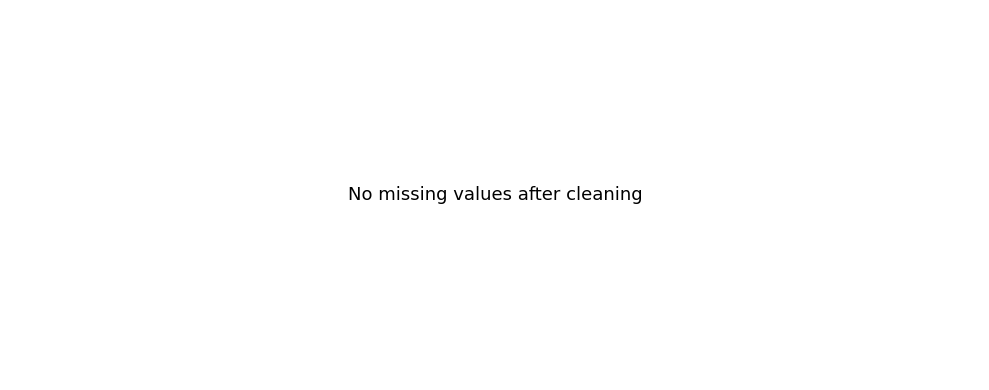

In [35]:
# Plot missingness percentages
missing_nonzero = missing_report[missing_report["missing_pct"] > 0].copy()

plt.figure(figsize=(10, max(4, len(missing_nonzero) * 0.35)))
if missing_nonzero.empty:
    plt.text(0.5, 0.5, "No missing values after cleaning", ha="center", va="center", fontsize=13)
    plt.axis("off")
else:
    plt.barh(missing_nonzero["column"], missing_nonzero["missing_pct"])
    plt.xlabel("Missing values (%)")
    plt.title("Missingness after cleaning")
    plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation
For this dataset, missingness is low in the structured questions after duplicate-field repair and anonymization.  
The main data quality issue is not missingness, but **schema irregularity** caused by the duplicated open-ended fields.

## 4. Respondent profile

This section characterizes the sample before focusing on AI-specific questions.

In [36]:
def plot_categorical_distribution(series, title, order=None, normalize=True, top_n=None):
    s = series.dropna()
    if order is not None:
        counts = s.value_counts().reindex(order, fill_value=0)
    else:
        counts = s.value_counts()
    if top_n is not None:
        counts = counts.head(top_n)
    values = counts / counts.sum() * 100 if normalize else counts
    xlabel = "Percentage of respondents" if normalize else "Count"
    plt.figure(figsize=(10, max(4, len(counts) * 0.45)))
    plt.barh(counts.index.astype(str), values.values)
    for i, v in enumerate(values.values):
        suffix = "%" if normalize else ""
        plt.text(v + (0.3 if normalize else 0.05), i, f"{v:.1f}{suffix}" if normalize else f"{int(v)}", va="center")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

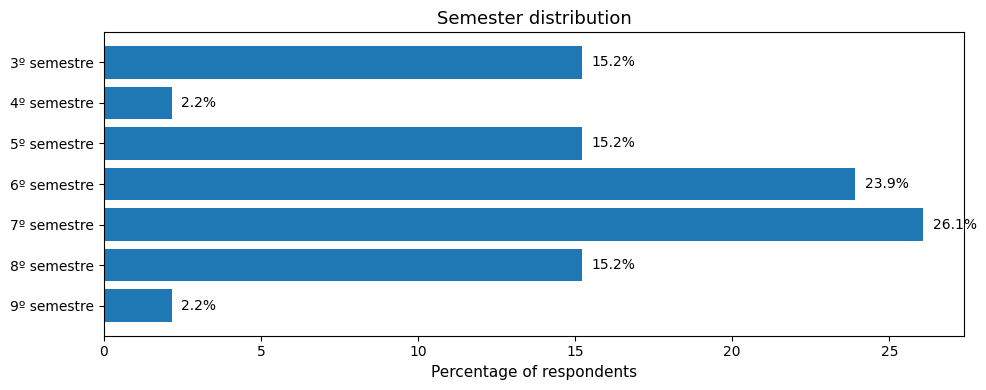

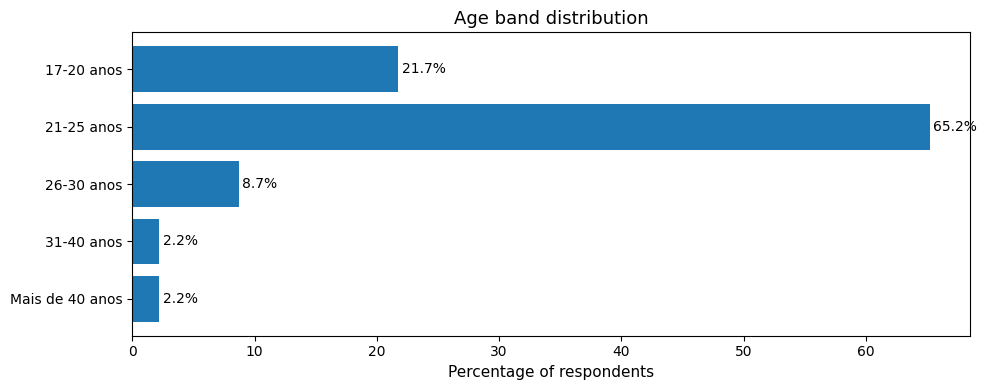

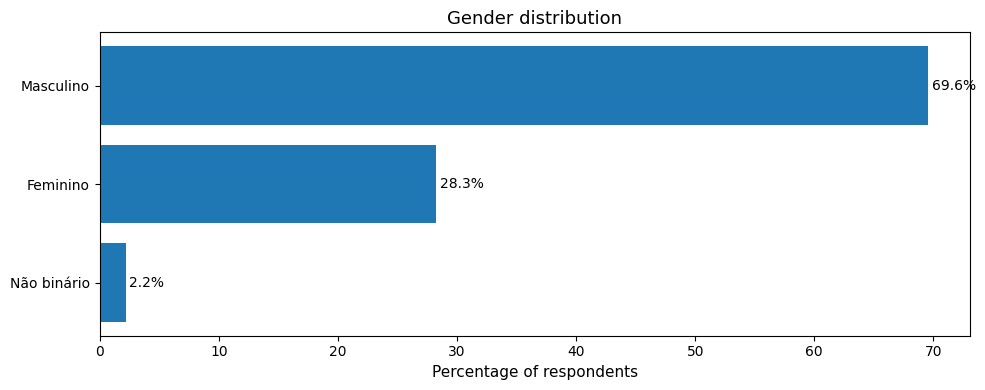

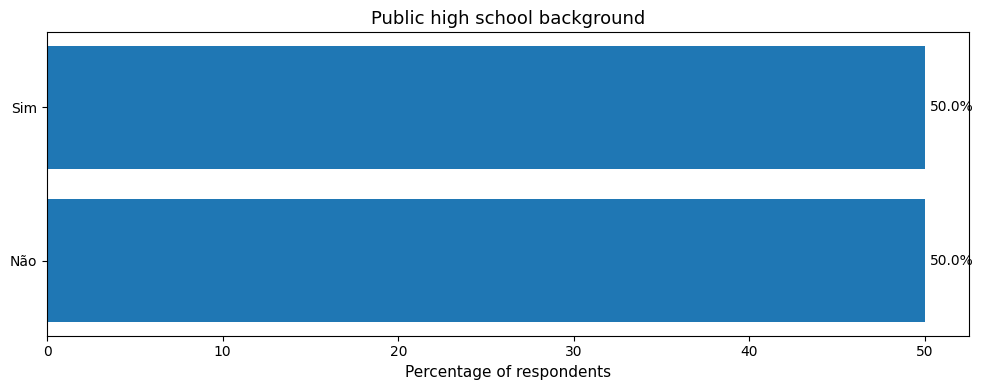

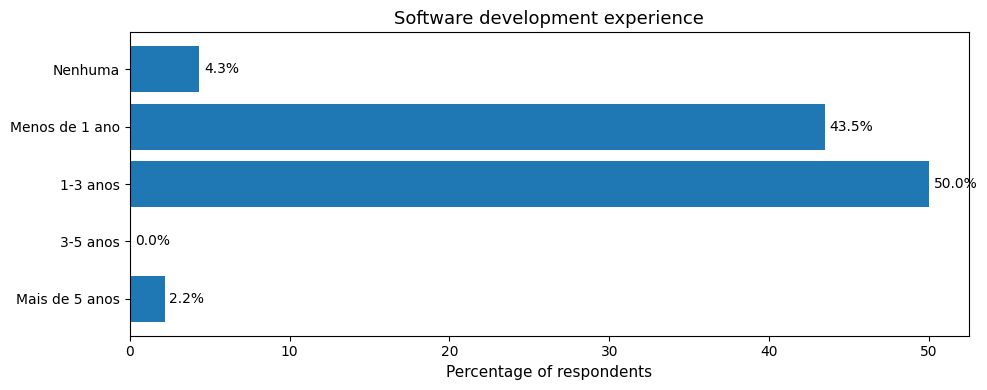

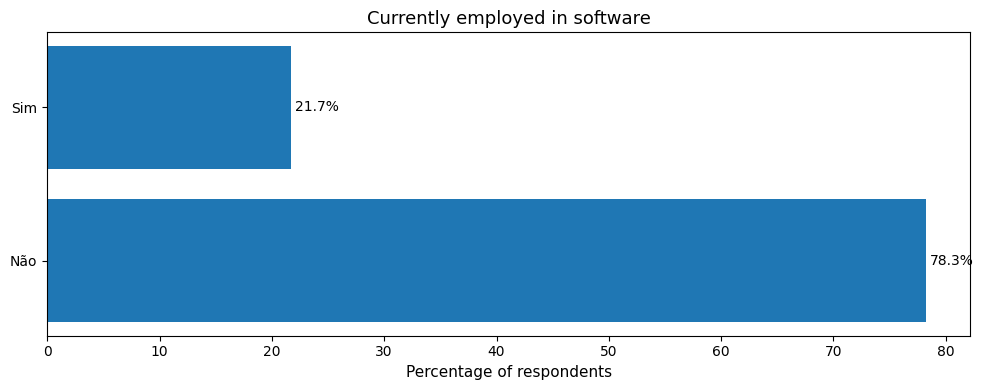

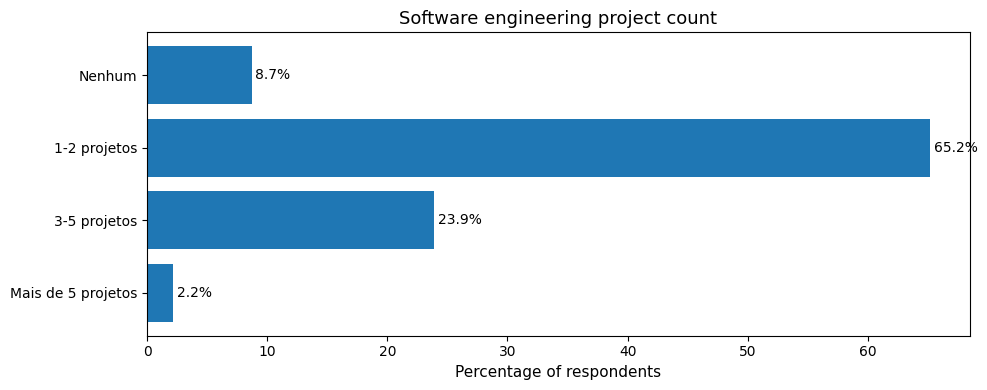

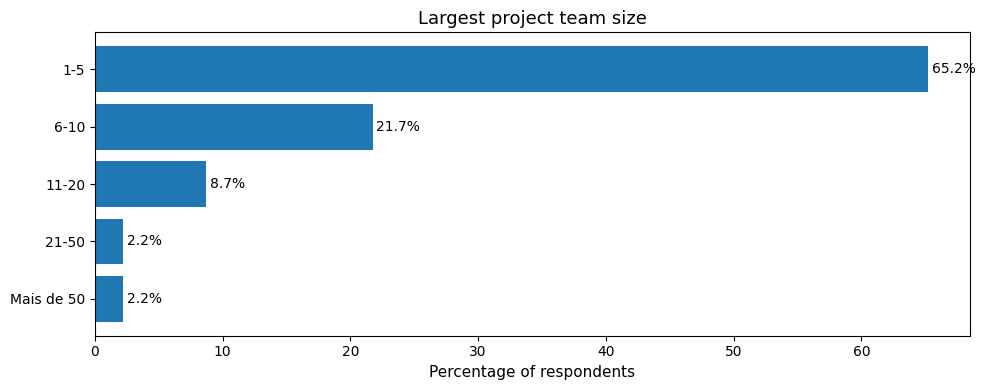

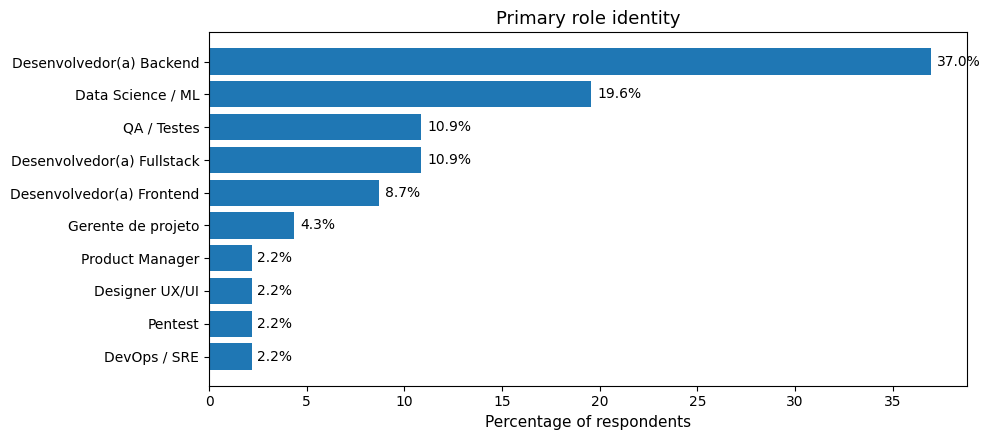

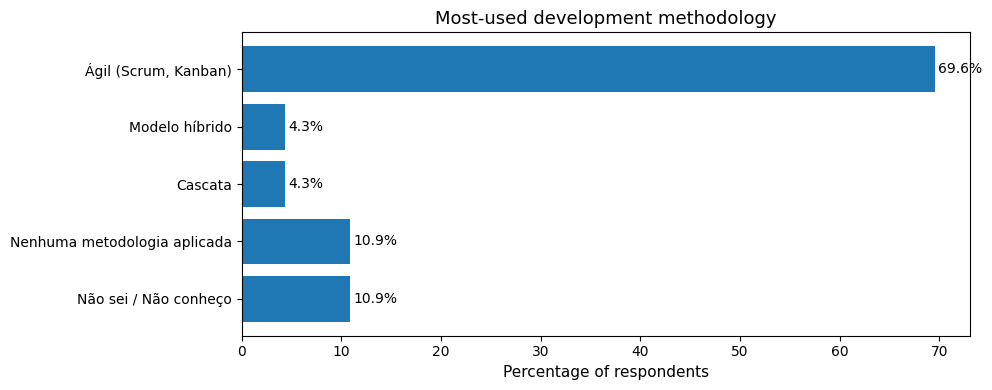

In [37]:
profile_columns = [
    ("semester", semester_order, "Semester distribution"),
    ("age_band", age_order, "Age band distribution"),
    ("gender", None, "Gender distribution"),
    ("public_high_school", ["Sim", "Não"], "Public high school background"),
    ("software_experience", software_experience_order, "Software development experience"),
    ("employed_in_software", ["Sim", "Não"], "Currently employed in software"),
    ("project_count", project_count_order, "Software engineering project count"),
    ("largest_team_size", team_size_order, "Largest project team size"),
    ("primary_role", None, "Primary role identity"),
    ("methodology", methodology_order, "Most-used development methodology"),
]

for col, order, title in profile_columns:
    plot_categorical_distribution(analysis_df[col], title=title, order=order, normalize=True)

In [38]:
profile_summary = pd.DataFrame({
    "metric": [
        "Sample size",
        "Median semester (approx.)",
        "Share with software employment",
        "Share with prior project using GenAI functionality",
        "Share using GenAI weekly/daily in general",
        "Share using GenAI weekly/daily in software engineering"
    ],
    "value": [
        len(analysis_df),
        analysis_df["semester"].str.extract(r"(\d+)").astype(float).median().iloc[0],
        round(analysis_df["employed_in_software_num"].mean() * 100, 1),
        round(analysis_df["prior_project_with_genai_feature_num"].mean() * 100, 1),
        round(analysis_df["daily_or_weekly_general_usage"].mean() * 100, 1),
        round(analysis_df["high_se_usage"].mean() * 100, 1),
    ]
})
display(profile_summary)

,metric,value
0,Sample size,46.0
1,Median semester (approx.),6.0
2,Share with software employment,21.7
3,Share with prior project using GenAI functiona...,41.3
4,Share using GenAI weekly/daily in general,69.6
5,Share using GenAI weekly/daily in software eng...,58.7


## 5. Adoption of generative AI

This section examines:
- overall usage frequency
- software-engineering-specific usage frequency
- activities supported by GenAI
- tools used in the last 12 months
- intensity of tool/activity diversification

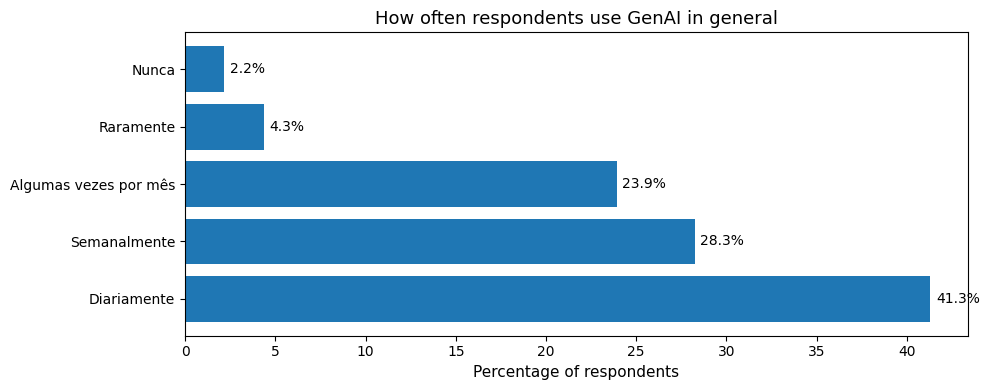

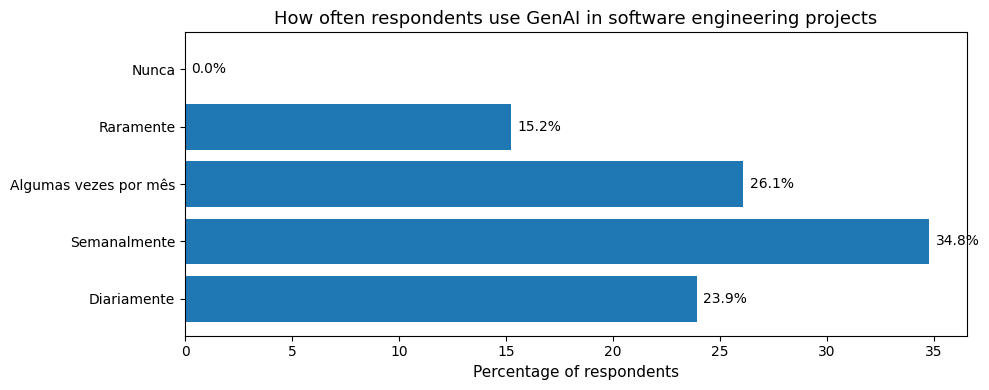

In [39]:
plot_categorical_distribution(
    analysis_df["genai_general_frequency"],
    title="How often respondents use GenAI in general",
    order=["Nunca", "Raramente", "Algumas vezes por mês", "Semanalmente", "Diariamente"],
    normalize=True
)

plot_categorical_distribution(
    analysis_df["genai_se_frequency"],
    title="How often respondents use GenAI in software engineering projects",
    order=["Nunca", "Raramente", "Algumas vezes por mês", "Semanalmente", "Diariamente"],
    normalize=True
)

In [40]:
# Crosstab: general use vs software-engineering use
ct = pd.crosstab(
    analysis_df["genai_general_frequency"],
    analysis_df["genai_se_frequency"],
    normalize="index"
).reindex(
    ["Nunca", "Raramente", "Algumas vezes por mês", "Semanalmente", "Diariamente"]
).fillna(0)

display(ct.style.format("{:.2%}"))

genai_se_frequency,Algumas vezes por mês,Diariamente,Raramente,Semanalmente
genai_general_frequency,,,,
Nunca,0.00%,0.00%,100.00%,0.00%
Raramente,50.00%,0.00%,50.00%,0.00%
Algumas vezes por mês,63.64%,0.00%,9.09%,27.27%
Semanalmente,30.77%,15.38%,15.38%,38.46%
Diariamente,0.00%,47.37%,10.53%,42.11%


,count
Pesquisa / Perguntas gerais / Uso Pessoal,42
Geração de código,30
Depuração / debug,27
Brainstorming de ideias,26
Documentação,20
Refatoração,14
Escrita de testes,12
Análise de requisitos,11
Prototipação,10
Organização de trabalhos acadêmicos.,1


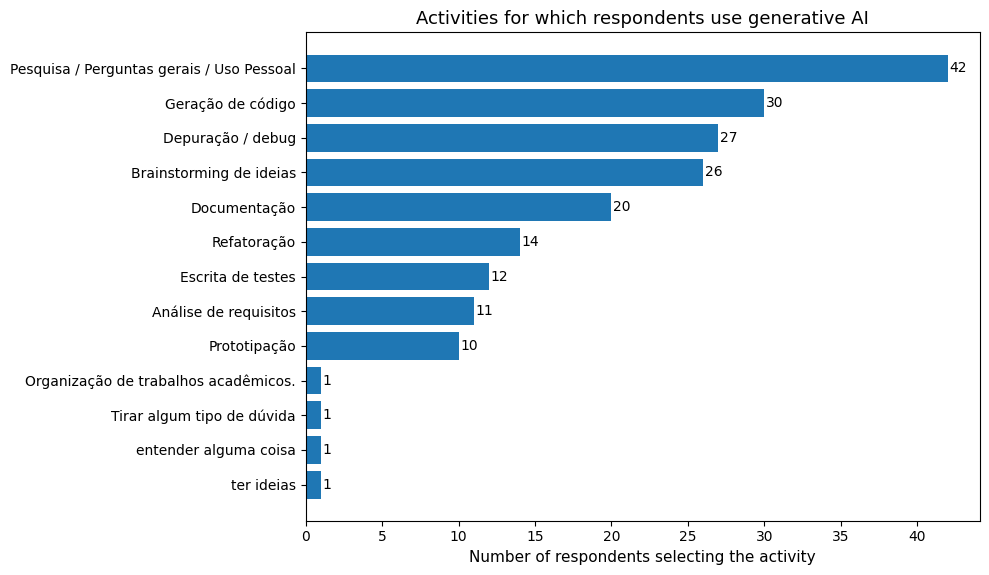

In [41]:
# Multi-select: activities
activity_counts = multiselect_counts(analysis_df["genai_activities"])
display(activity_counts.to_frame("count"))

plt.figure(figsize=(10, max(4, len(activity_counts) * 0.45)))
plt.barh(activity_counts.index, activity_counts.values)
for i, v in enumerate(activity_counts.values):
    plt.text(v + 0.1, i, str(int(v)), va="center")
plt.title("Activities for which respondents use generative AI")
plt.xlabel("Number of respondents selecting the activity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,count
ChatGPT,46
Gemini,34
DeepSeek,31
GitHub Copilot,18
Claude,7
Cursor,3
n8n,2
Lovable,1
v0,1
Microsoft copilot,1


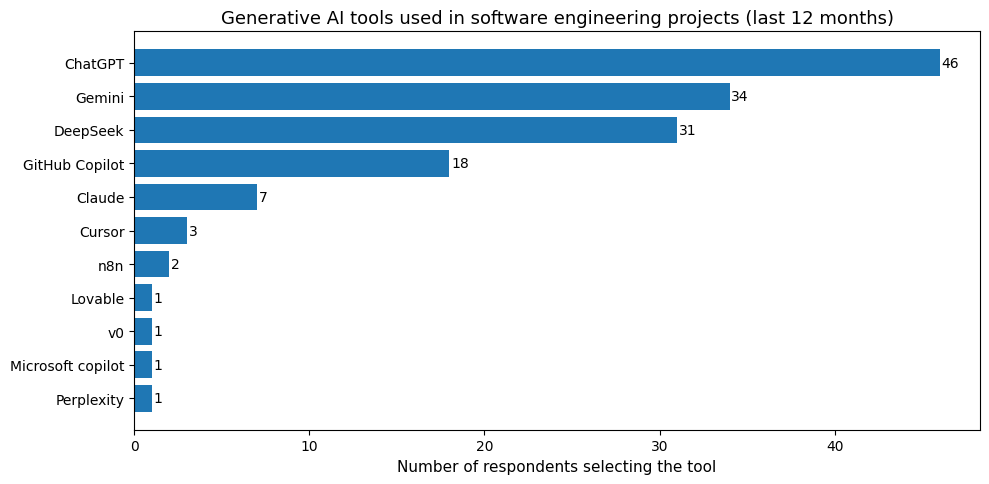

In [42]:
# Multi-select: tools
tool_counts = multiselect_counts(analysis_df["genai_tools_last_12m"])
display(tool_counts.to_frame("count"))

plt.figure(figsize=(10, max(4, len(tool_counts) * 0.45)))
plt.barh(tool_counts.index, tool_counts.values)
for i, v in enumerate(tool_counts.values):
    plt.text(v + 0.1, i, str(int(v)), va="center")
plt.title("Generative AI tools used in software engineering projects (last 12 months)")
plt.xlabel("Number of respondents selecting the tool")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

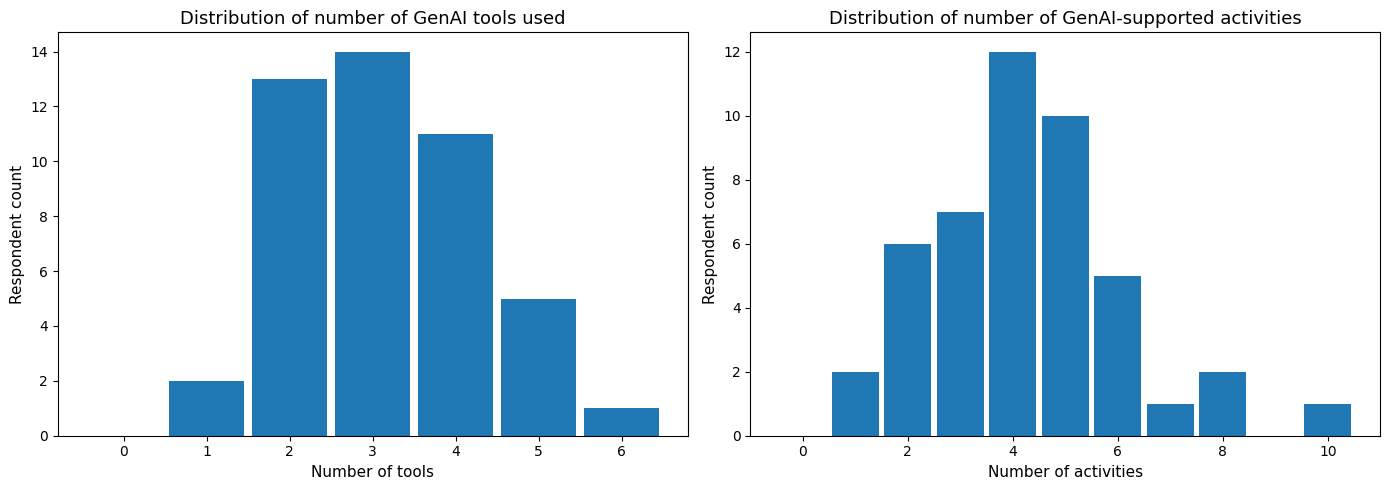

,count,mean,std,min,25%,50%,75%,max
n_genai_tools,46.0,3.152174,1.154073,1.0,2.0,3.0,4.0,6.0
n_genai_activities,46.0,4.260870,1.843123,1.0,3.0,4.0,5.0,10.0


In [43]:
# Number of tools and activities per respondent
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(analysis_df["n_genai_tools"], bins=np.arange(-0.5, analysis_df["n_genai_tools"].max() + 1.5, 1), rwidth=0.9)
axes[0].set_title("Distribution of number of GenAI tools used")
axes[0].set_xlabel("Number of tools")
axes[0].set_ylabel("Respondent count")

axes[1].hist(analysis_df["n_genai_activities"], bins=np.arange(-0.5, analysis_df["n_genai_activities"].max() + 1.5, 1), rwidth=0.9)
axes[1].set_title("Distribution of number of GenAI-supported activities")
axes[1].set_xlabel("Number of activities")
axes[1].set_ylabel("Respondent count")

plt.tight_layout()
plt.show()

display(
    analysis_df[["n_genai_tools", "n_genai_activities"]]
    .describe()
    .T
)

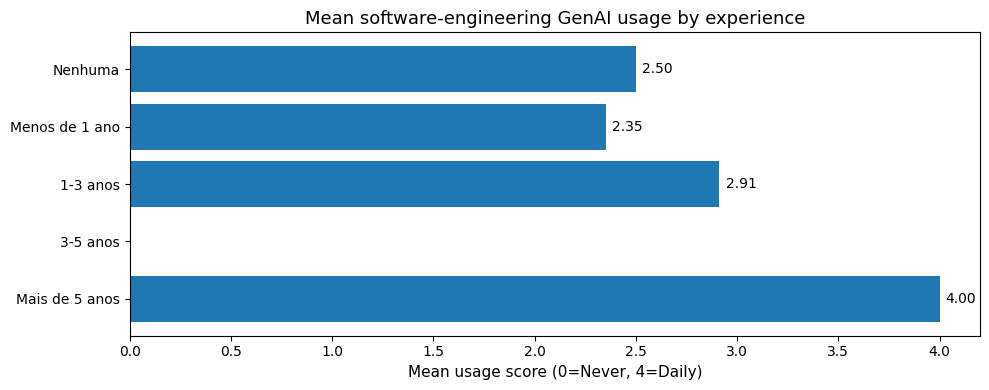

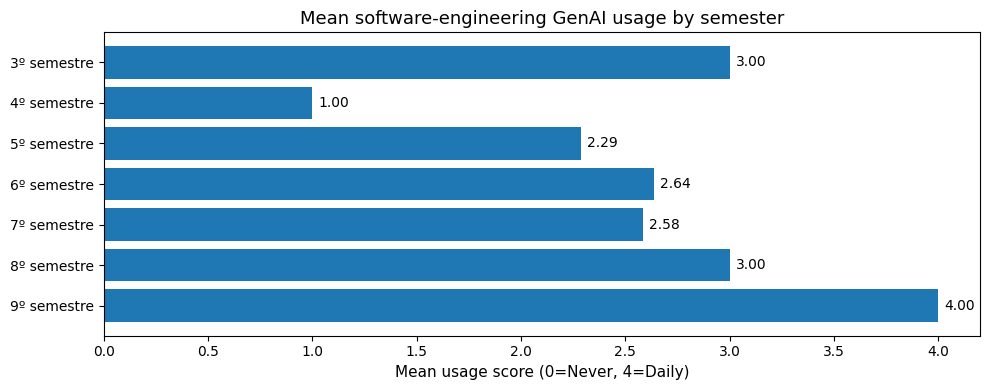

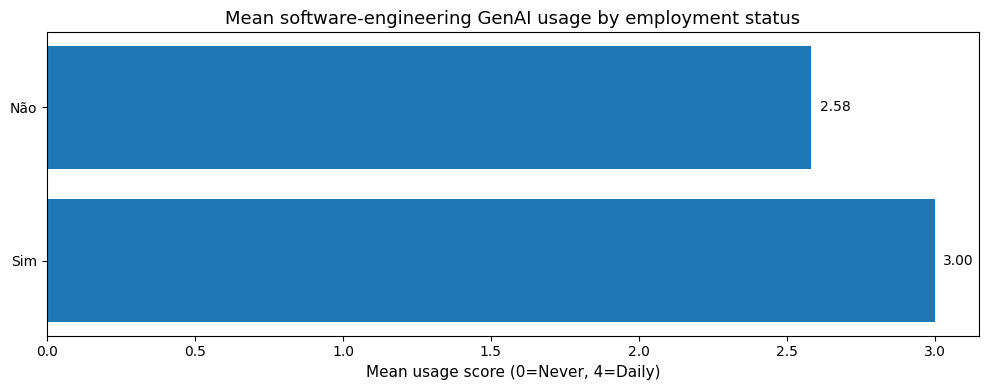

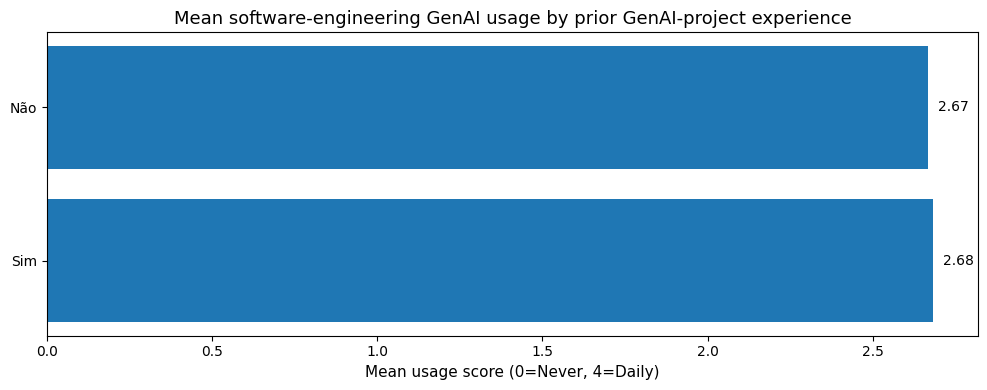

In [44]:
# Adoption by subgroup
def ordered_mean_by_group(df, group_col, value_col, order=None):
    out = df.groupby(group_col)[value_col].mean().sort_values(ascending=False)
    if order is not None:
        out = out.reindex(order)
    return out

subgroup_specs = [
    ("software_experience", software_experience_order, "Mean software-engineering GenAI usage by experience"),
    ("semester", semester_order, "Mean software-engineering GenAI usage by semester"),
    ("employed_in_software", ["Não", "Sim"], "Mean software-engineering GenAI usage by employment status"),
    ("prior_project_with_genai_feature", ["Não", "Sim"], "Mean software-engineering GenAI usage by prior GenAI-project experience"),
]

for group_col, order, title in subgroup_specs:
    means = ordered_mean_by_group(analysis_df, group_col, "genai_se_frequency_num", order=order)
    plt.figure(figsize=(10, max(4, len(means) * 0.45)))
    plt.barh(means.index.astype(str), means.values)
    for i, v in enumerate(means.values):
        plt.text(v + 0.03, i, f"{v:.2f}", va="center")
    plt.title(title)
    plt.xlabel("Mean usage score (0=Never, 4=Daily)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 6. Perception of generative AI in software engineering

This section converts the agreement statements into ordinal scores:
- 1 = strongly disagree
- 2 = disagree
- 3 = neutral
- 4 = agree
- 5 = strongly agree

In [45]:
likert_labels = {
    "likert_useful": "GenAI tools are useful",
    "likert_productivity": "GenAI increases my productivity",
    "likert_quality": "GenAI improves software quality",
    "likert_flow_change": "GenAI changes development flow",
    "likert_any_methodology": "Any methodology can work with GenAI",
    "likert_methodology_fit": "Some methodologies fit GenAI better",
    "likert_new_competencies": "GenAI requires new competencies",
    "likert_new_roles": "New professional roles will emerge",
    "likert_confidence_ai_code": "I feel confident reviewing/integrating AI-generated code"
}

likert_order = [
    "Discordo totalmente",
    "Discordo",
    "Neutro",
    "Concordo",
    "Concordo totalmente"
]

likert_dist = []
for col, label in likert_labels.items():
    row = analysis_df[col].value_counts(normalize=True).reindex(likert_order, fill_value=0)
    row.name = label
    likert_dist.append(row)

likert_dist = pd.DataFrame(likert_dist)
display(likert_dist.style.format("{:.1%}"))

,Discordo totalmente,Discordo,Neutro,Concordo,Concordo totalmente
GenAI tools are useful,0.0%,0.0%,2.2%,39.1%,58.7%
GenAI increases my productivity,0.0%,0.0%,6.5%,50.0%,43.5%
GenAI improves software quality,0.0%,8.7%,45.7%,28.3%,17.4%
GenAI changes development flow,0.0%,6.5%,28.3%,37.0%,28.3%
Any methodology can work with GenAI,0.0%,15.2%,45.7%,34.8%,4.3%
Some methodologies fit GenAI better,0.0%,10.9%,43.5%,32.6%,13.0%
GenAI requires new competencies,2.2%,10.9%,17.4%,39.1%,30.4%
New professional roles will emerge,0.0%,4.3%,8.7%,30.4%,56.5%
I feel confident reviewing/integrating AI-generated code,0.0%,19.6%,32.6%,30.4%,17.4%


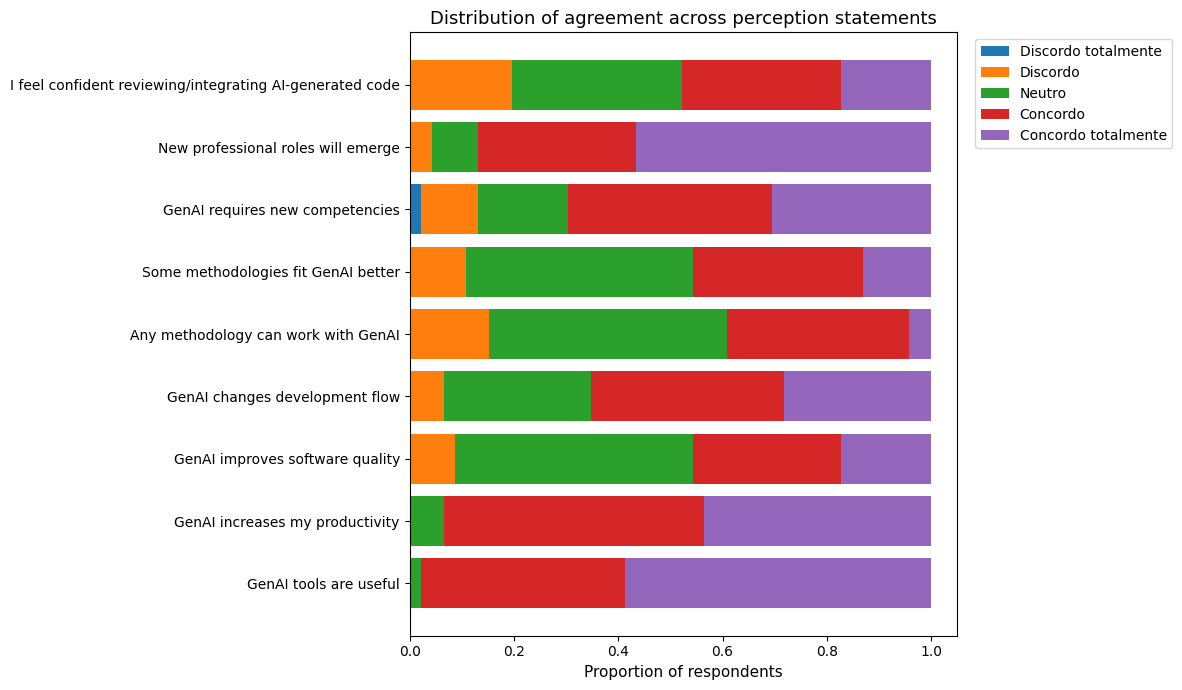

In [46]:
# Horizontal stacked Likert chart
plot_df = likert_dist.copy()

left = np.zeros(len(plot_df))
plt.figure(figsize=(12, 7))
for response in likert_order:
    vals = plot_df[response].values
    plt.barh(plot_df.index, vals, left=left, label=response)
    left += vals

plt.title("Distribution of agreement across perception statements")
plt.xlabel("Proportion of respondents")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

,mean_score
Any methodology can work with GenAI,3.282609
I feel confident reviewing/integrating AI-generated code,3.456522
Some methodologies fit GenAI better,3.478261
GenAI improves software quality,3.543478
GenAI requires new competencies,3.847826
GenAI changes development flow,3.869565
GenAI increases my productivity,4.369565
New professional roles will emerge,4.391304
GenAI tools are useful,4.565217


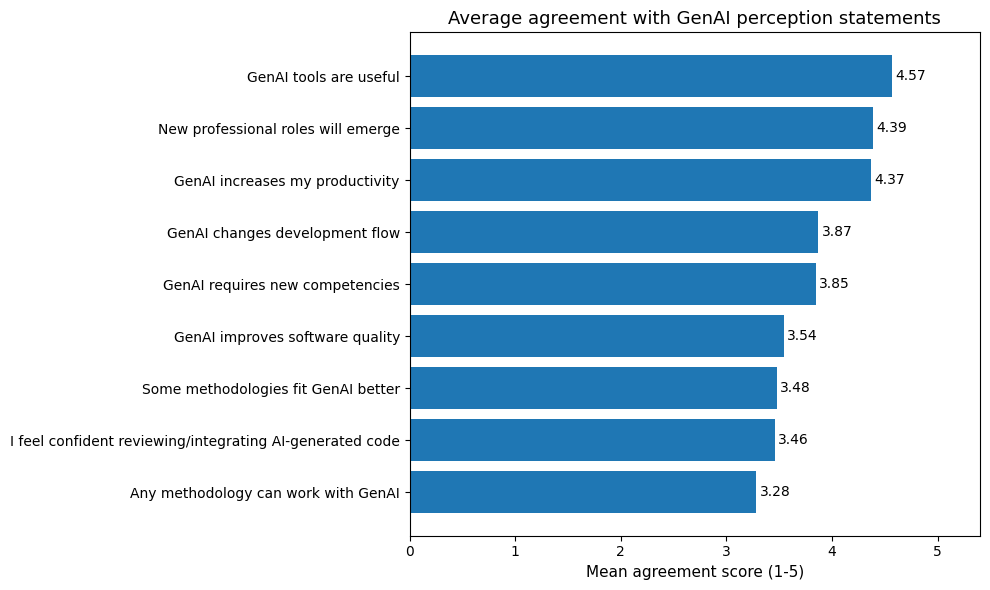

In [47]:
# Mean item scores
mean_item_scores = (
    analysis_df[[c + "_num" for c in likert_cols]]
    .mean()
    .rename(index={c + "_num": label for c, label in likert_labels.items()})
    .sort_values()
)

display(mean_item_scores.to_frame("mean_score"))

plt.figure(figsize=(10, 6))
plt.barh(mean_item_scores.index, mean_item_scores.values)
for i, v in enumerate(mean_item_scores.values):
    plt.text(v + 0.03, i, f"{v:.2f}", va="center")
plt.xlim(0, 5.4)
plt.xlabel("Mean agreement score (1-5)")
plt.title("Average agreement with GenAI perception statements")
plt.tight_layout()
plt.show()

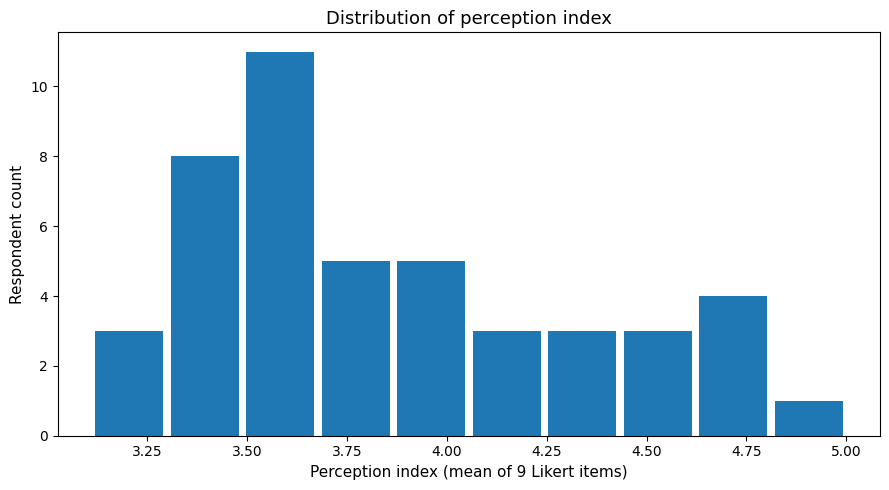

,perception_index
count,46.000000
mean,3.867150
std,0.473506
min,3.111111
25%,3.555556
50%,3.777778
75%,4.194444
max,5.000000


In [48]:
# Perception index distribution
plt.figure(figsize=(9, 5))
plt.hist(analysis_df["perception_index"], bins=10, rwidth=0.9)
plt.title("Distribution of perception index")
plt.xlabel("Perception index (mean of 9 Likert items)")
plt.ylabel("Respondent count")
plt.tight_layout()
plt.show()

display(analysis_df["perception_index"].describe().to_frame("perception_index"))

### Interpretation
The perception index summarizes overall orientation toward GenAI in software engineering.  
It should be read as a **composite exploratory score**, not as a validated psychometric scale.

## 7. Perceived impact on software engineering roles

These items were already numeric on a 1–5 agreement scale and can be compared directly.

,mean_impact_score
Project manager,1.826087
QA,2.065217
Product manager,2.086957
Scrum Master,2.326087
Backend,2.391304
Frontend,2.739130


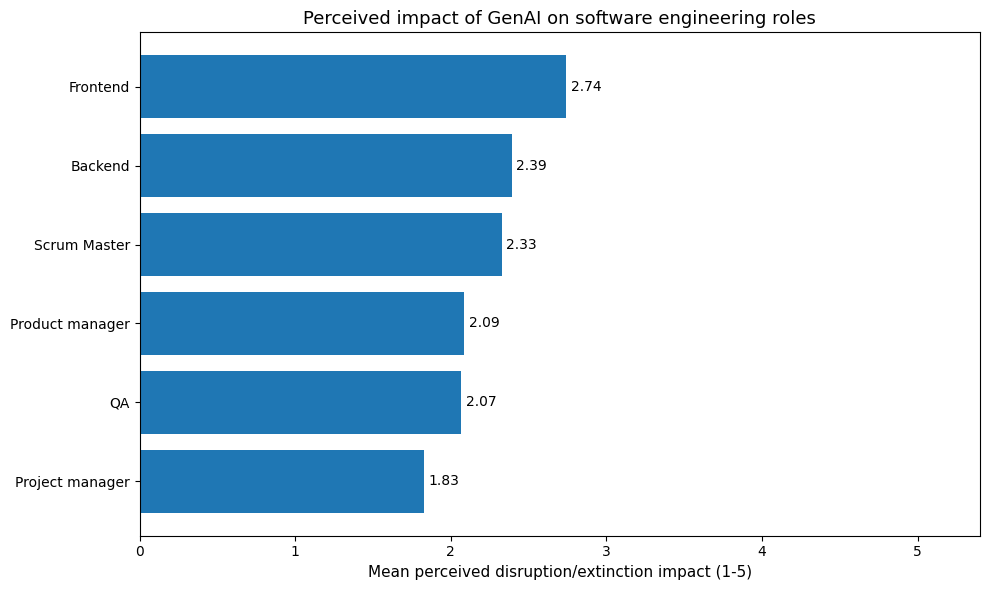

In [49]:
role_labels = {
    "role_backend_impact": "Backend",
    "role_frontend_impact": "Frontend",
    "role_qa_impact": "QA",
    "role_pmgr_impact": "Project manager",
    "role_product_manager_impact": "Product manager",
    "role_scrum_master_impact": "Scrum Master",
}

role_means = analysis_df[list(role_labels)].mean().rename(index=role_labels).sort_values()
display(role_means.to_frame("mean_impact_score"))

plt.figure(figsize=(10, 6))
plt.barh(role_means.index, role_means.values)
for i, v in enumerate(role_means.values):
    plt.text(v + 0.03, i, f"{v:.2f}", va="center")
plt.xlim(0, 5.4)
plt.xlabel("Mean perceived disruption/extinction impact (1-5)")
plt.title("Perceived impact of GenAI on software engineering roles")
plt.tight_layout()
plt.show()

In [50]:
# Distribution by role item
role_item_summary = analysis_df[list(role_labels)].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
role_item_summary.index = role_item_summary.index.map(role_labels)
display(role_item_summary)

,mean,std,min,25%,50%,75%,max
Backend,2.391304,0.954015,1.0,2.0,2.0,3.0,5.0
Frontend,2.739130,1.104230,1.0,2.0,3.0,3.0,5.0
QA,2.065217,1.062537,1.0,1.0,2.0,2.0,5.0
Project manager,1.826087,1.017717,1.0,1.0,1.5,2.0,5.0
Product manager,2.086957,1.029047,1.0,1.0,2.0,3.0,5.0
Scrum Master,2.326087,0.990047,1.0,2.0,2.0,3.0,5.0


## 8. Relationship analysis and exploratory statistical testing

Because the sample is modest (`n = 46`), the analysis uses non-parametric or contingency-based methods.

Tests included:
- **Spearman correlation** for ordinal/continuous-like association
- **Mann–Whitney U** for two-group comparisons
- **Kruskal–Wallis** for >2 group comparisons
- **Chi-square** and **Cramér's V** for contingency relationships

These results are exploratory and should be interpreted with caution.

In [51]:
def cramers_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    r, k = table.shape
    if n == 0:
        return np.nan
    return np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))

def mannwhitney_compare(df, value_col, group_col, group_order):
    g1 = df.loc[df[group_col] == group_order[0], value_col].dropna()
    g2 = df.loc[df[group_col] == group_order[1], value_col].dropna()
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    return {
        "group_col": group_col,
        "value_col": value_col,
        "group_1": group_order[0],
        "group_2": group_order[1],
        "n_1": len(g1),
        "n_2": len(g2),
        "median_1": float(g1.median()),
        "median_2": float(g2.median()),
        "u_stat": float(stat),
        "p_value": float(p),
    }

In [52]:
# Spearman correlations
spearman_results = []

for x_col, x_label in [
    ("genai_general_frequency_num", "General GenAI usage frequency"),
    ("genai_se_frequency_num", "SE-specific GenAI usage frequency"),
    ("n_genai_tools", "Number of GenAI tools used"),
    ("n_genai_activities", "Number of GenAI-supported activities"),
]:
    for y_col, y_label in [
        ("perception_index", "Perception index"),
        ("role_disruption_index", "Role disruption index"),
        ("automation_revision_needed", "Expected need for revision of automated outputs"),
        ("automation_speed_up", "Belief that automation will speed development"),
    ]:
        sub = analysis_df[[x_col, y_col]].dropna()
        rho, p = spearmanr(sub[x_col], sub[y_col])
        spearman_results.append({
            "x": x_label,
            "y": y_label,
            "n": len(sub),
            "spearman_rho": rho,
            "p_value": p
        })

spearman_results = pd.DataFrame(spearman_results).sort_values(["p_value", "spearman_rho"], ascending=[True, False])
display(spearman_results)

,x,y,n,spearman_rho,p_value
3,General GenAI usage frequency,Belief that automation will speed development,46,0.420071,0.003656
0,General GenAI usage frequency,Perception index,46,0.397565,0.006219
4,SE-specific GenAI usage frequency,Perception index,46,0.329756,0.025223
7,SE-specific GenAI usage frequency,Belief that automation will speed development,46,0.258821,0.082417
11,Number of GenAI tools used,Belief that automation will speed development,46,0.246625,0.098476
2,General GenAI usage frequency,Expected need for revision of automated outputs,46,0.227965,0.127578
8,Number of GenAI tools used,Perception index,46,0.207775,0.165873
15,Number of GenAI-supported activities,Belief that automation will speed development,46,0.176673,0.240177
12,Number of GenAI-supported activities,Perception index,46,0.174392,0.246397
9,Number of GenAI tools used,Role disruption index,46,-0.109235,0.469898


In [53]:
# Two-group comparisons using Mann-Whitney U
mw_results = []

comparisons = [
    ("perception_index", "employed_in_software", ["Não", "Sim"]),
    ("perception_index", "prior_project_with_genai_feature", ["Não", "Sim"]),
    ("genai_se_frequency_num", "employed_in_software", ["Não", "Sim"]),
    ("genai_se_frequency_num", "prior_project_with_genai_feature", ["Não", "Sim"]),
    ("role_disruption_index", "prior_project_with_genai_feature", ["Não", "Sim"]),
]

for value_col, group_col, group_order in comparisons:
    mw_results.append(mannwhitney_compare(analysis_df, value_col, group_col, group_order))

mw_results = pd.DataFrame(mw_results).sort_values("p_value")
display(mw_results)

,group_col,value_col,group_1,group_2,n_1,n_2,median_1,median_2,u_stat,p_value
4,prior_project_with_genai_feature,role_disruption_index,Não,Sim,27,19,2.333333,2.000000,330.0,0.102223
2,employed_in_software,genai_se_frequency_num,Não,Sim,36,10,3.000000,3.000000,137.5,0.244434
1,prior_project_with_genai_feature,perception_index,Não,Sim,27,19,3.666667,3.888889,240.0,0.720055
0,employed_in_software,perception_index,Não,Sim,36,10,3.777778,3.666667,183.0,0.946704
3,prior_project_with_genai_feature,genai_se_frequency_num,Não,Sim,27,19,3.000000,3.000000,257.5,0.990738


In [54]:
# Kruskal-Wallis: experience groups and semester groups
kw_results = []

for group_col, order in [
    ("software_experience", software_experience_order),
    ("semester", semester_order),
]:
    for value_col in ["perception_index", "genai_se_frequency_num", "role_disruption_index"]:
        groups = []
        labels = []
        for category in order:
            vals = analysis_df.loc[analysis_df[group_col] == category, value_col].dropna()
            if len(vals) > 0:
                groups.append(vals)
                labels.append(category)
        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            kw_results.append({
                "group_col": group_col,
                "value_col": value_col,
                "tested_categories": labels,
                "h_stat": float(stat),
                "p_value": float(p)
            })

kw_results = pd.DataFrame(kw_results).sort_values("p_value")
display(kw_results)

,group_col,value_col,tested_categories,h_stat,p_value
2,software_experience,role_disruption_index,"[Nenhuma, Menos de 1 ano, 1-3 anos, Mais de 5 ...",8.171531,0.042597
1,software_experience,genai_se_frequency_num,"[Nenhuma, Menos de 1 ano, 1-3 anos, Mais de 5 ...",5.183195,0.158864
0,software_experience,perception_index,"[Nenhuma, Menos de 1 ano, 1-3 anos, Mais de 5 ...",3.644294,0.302524
4,semester,genai_se_frequency_num,"[3º semestre, 4º semestre, 5º semestre, 6º sem...",6.767012,0.342932
3,semester,perception_index,"[3º semestre, 4º semestre, 5º semestre, 6º sem...",4.022048,0.673693
5,semester,role_disruption_index,"[3º semestre, 4º semestre, 5º semestre, 6º sem...",2.607165,0.856287


In [55]:
# Contingency analyses
contingency_results = []

for row_var, col_var in [
    ("high_se_usage", "prior_project_with_genai_feature"),
    ("high_se_usage", "employed_in_software"),
    ("daily_or_weekly_general_usage", "prior_project_with_genai_feature"),
]:
    table = pd.crosstab(analysis_df[row_var], analysis_df[col_var])
    chi2, p, dof, expected = chi2_contingency(table)
    contingency_results.append({
        "row_var": row_var,
        "col_var": col_var,
        "table_shape": table.shape,
        "chi2": float(chi2),
        "dof": int(dof),
        "p_value": float(p),
        "cramers_v": float(cramers_v(table))
    })
    print(f"Contingency table: {row_var} x {col_var}")
    display(table)

contingency_results = pd.DataFrame(contingency_results).sort_values("p_value")
display(contingency_results)

Contingency table: high_se_usage x prior_project_with_genai_feature


prior_project_with_genai_feature,Não,Sim
high_se_usage,,
False,11,8
True,16,11


Contingency table: high_se_usage x employed_in_software


employed_in_software,Não,Sim
high_se_usage,,
False,16,3
True,20,7


Contingency table: daily_or_weekly_general_usage x prior_project_with_genai_feature


prior_project_with_genai_feature,Não,Sim
daily_or_weekly_general_usage,,
False,9,5
True,18,14


,row_var,col_var,table_shape,chi2,dof,p_value,cramers_v
1,high_se_usage,employed_in_software,"(2, 2)",0.209476,1,0.647179,0.067482
2,daily_or_weekly_general_usage,prior_project_with_genai_feature,"(2, 2)",0.033826,1,0.854078,0.027117
0,high_se_usage,prior_project_with_genai_feature,"(2, 2)",0.000000,1,1.000000,0.000000


## 9. Segmentation of respondents by adoption intensity

A simple exploratory adoption score is created from:
- general GenAI usage frequency
- SE-specific GenAI usage frequency
- number of GenAI tools used
- number of GenAI-supported activities
- prior participation in projects with GenAI functionality

This is not a validated scale; it is only a segmentation device for EDA.

In [56]:
analysis_df["adoption_score_raw"] = (
    analysis_df["genai_general_frequency_num"].fillna(0)
    + analysis_df["genai_se_frequency_num"].fillna(0)
    + analysis_df["n_genai_tools"].fillna(0)
    + analysis_df["n_genai_activities"].fillna(0)
    + analysis_df["prior_project_with_genai_feature_num"].fillna(0)
)

analysis_df["adoption_segment"] = pd.qcut(
    analysis_df["adoption_score_raw"],
    q=3,
    labels=["Lower adoption", "Moderate adoption", "Higher adoption"],
    duplicates="drop"
)

display(
    analysis_df[["adoption_score_raw", "adoption_segment"]]
    .groupby("adoption_segment")
    .agg(["count", "mean", "min", "max"])
)

adoption_score_raw                   
                               count       mean min max
adoption_segment                                       
Lower adoption                    19  10.000000   4  12
Moderate adoption                 13  13.769231  13  15
Higher adoption                   14  18.071429  16  24

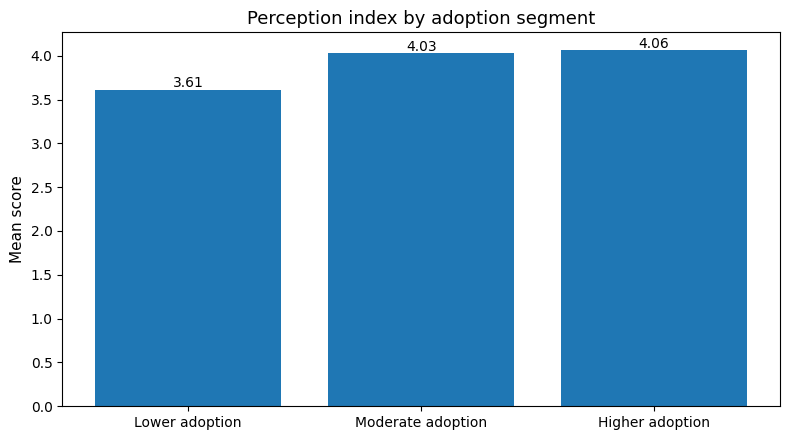

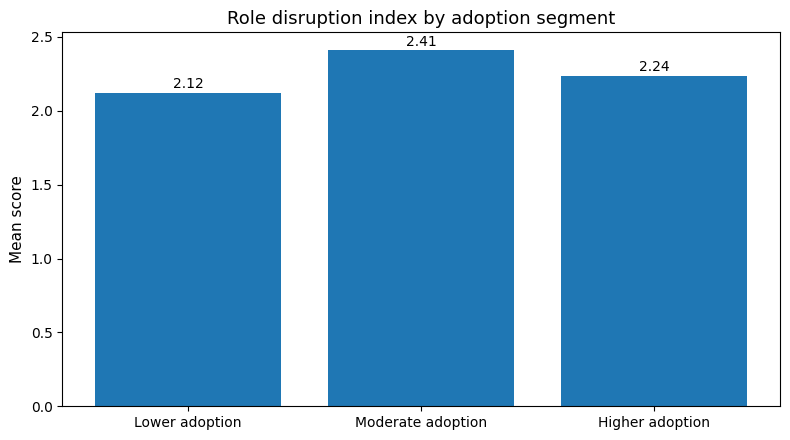

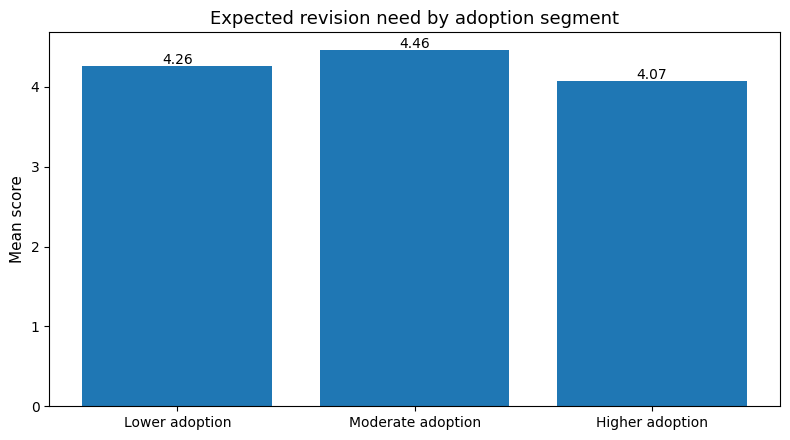

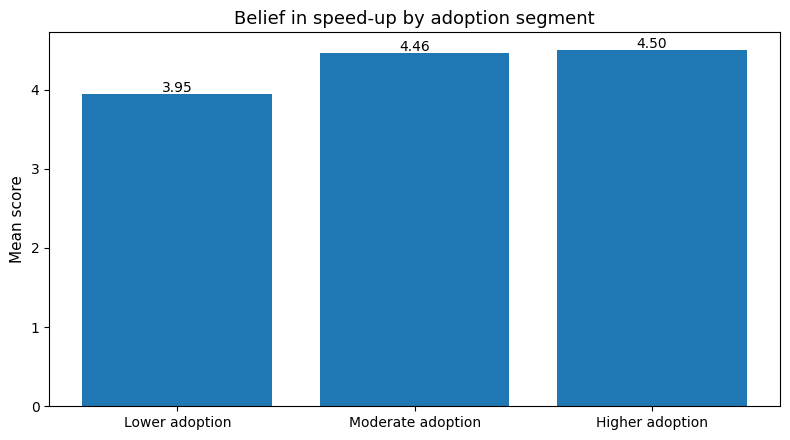

In [57]:
# Segment comparison
segment_order = ["Lower adoption", "Moderate adoption", "Higher adoption"]

for metric, title in [
    ("perception_index", "Perception index by adoption segment"),
    ("role_disruption_index", "Role disruption index by adoption segment"),
    ("automation_revision_needed", "Expected revision need by adoption segment"),
    ("automation_speed_up", "Belief in speed-up by adoption segment"),
]:
    means = analysis_df.groupby("adoption_segment")[metric].mean().reindex(segment_order)
    plt.figure(figsize=(8, 4.5))
    plt.bar(means.index.astype(str), means.values)
    for i, v in enumerate(means.values):
        if pd.notna(v):
            plt.text(i, v + 0.03, f"{v:.2f}", ha="center")
    plt.title(title)
    plt.ylabel("Mean score")
    plt.tight_layout()
    plt.show()

## 10. Focused interpretation cells

The next cells automatically summarize the strongest descriptive patterns from the dataset.

In [58]:
# Top descriptive findings (programmatic summary)
summary_lines = []

summary_lines.append(f"- Sample size: **{len(analysis_df)} respondents**.")
summary_lines.append(
    f"- General GenAI use is common: **{analysis_df['daily_or_weekly_general_usage'].mean() * 100:.1f}%** report using it weekly or daily."
)
summary_lines.append(
    f"- SE-specific GenAI use is also substantial: **{analysis_df['high_se_usage'].mean() * 100:.1f}%** report weekly or daily use in software-engineering projects."
)
summary_lines.append(
    f"- Prior experience with GenAI functionality in projects: **{analysis_df['prior_project_with_genai_feature_num'].mean() * 100:.1f}%**."
)

top_tools = multiselect_counts(analysis_df["genai_tools_last_12m"]).head(3)
summary_lines.append(
    "- Most selected GenAI tools: " + ", ".join([f"**{idx} ({val})**" for idx, val in top_tools.items()]) + "."
)

top_activities = multiselect_counts(analysis_df["genai_activities"]).head(4)
summary_lines.append(
    "- Most common GenAI-supported activities: " + ", ".join([f"**{idx} ({val})**" for idx, val in top_activities.items()]) + "."
)

highest_perception = mean_item_scores.sort_values(ascending=False).head(3)
lowest_perception = mean_item_scores.sort_values(ascending=True).head(3)

summary_lines.append(
    "- Highest-agreement perception items: " + ", ".join([f"**{idx} ({val:.2f})**" for idx, val in highest_perception.items()]) + "."
)
summary_lines.append(
    "- Lowest-agreement perception items: " + ", ".join([f"**{idx} ({val:.2f})**" for idx, val in lowest_perception.items()]) + "."
)

most_disrupted_roles = role_means.sort_values(ascending=False).head(3)
least_disrupted_roles = role_means.sort_values(ascending=True).head(3)

summary_lines.append(
    "- Roles perceived as most impacted by GenAI: " + ", ".join([f"**{idx} ({val:.2f})**" for idx, val in most_disrupted_roles.items()]) + "."
)
summary_lines.append(
    "- Roles perceived as least impacted by GenAI: " + ", ".join([f"**{idx} ({val:.2f})**" for idx, val in least_disrupted_roles.items()]) + "."
)

display(Markdown("\n".join(summary_lines)))

- Sample size: **46 respondents**.
- General GenAI use is common: **69.6%** report using it weekly or daily.
- SE-specific GenAI use is also substantial: **58.7%** report weekly or daily use in software-engineering projects.
- Prior experience with GenAI functionality in projects: **41.3%**.
- Most selected GenAI tools: **ChatGPT (46)**, **Gemini (34)**, **DeepSeek (31)**.
- Most common GenAI-supported activities: **Pesquisa / Perguntas gerais / Uso Pessoal (42)**, **Geração de código (30)**, **Depuração / debug (27)**, **Brainstorming de ideias (26)**.
- Highest-agreement perception items: **GenAI tools are useful (4.57)**, **New professional roles will emerge (4.39)**, **GenAI increases my productivity (4.37)**.
- Lowest-agreement perception items: **Any methodology can work with GenAI (3.28)**, **I feel confident reviewing/integrating AI-generated code (3.46)**, **Some methodologies fit GenAI better (3.48)**.
- Roles perceived as most impacted by GenAI: **Frontend (2.74)**, **Backend (2.39)**, **Scrum Master (2.33)**.
- Roles perceived as least impacted by GenAI: **Project manager (1.83)**, **QA (2.07)**, **Product manager (2.09)**.

In [59]:
# Strongest exploratory statistical signals
top_spearman = spearman_results.head(5).copy()
top_mw = mw_results.head(5).copy()
top_ct = contingency_results.head(5).copy()

display(Markdown("### Strongest exploratory associations detected"))
display(top_spearman)

display(Markdown("### Strongest two-group contrasts detected"))
display(top_mw)

display(Markdown("### Strongest contingency relationships detected"))
display(top_ct)

### Strongest exploratory associations detected

,x,y,n,spearman_rho,p_value
3,General GenAI usage frequency,Belief that automation will speed development,46,0.420071,0.003656
0,General GenAI usage frequency,Perception index,46,0.397565,0.006219
4,SE-specific GenAI usage frequency,Perception index,46,0.329756,0.025223
7,SE-specific GenAI usage frequency,Belief that automation will speed development,46,0.258821,0.082417
11,Number of GenAI tools used,Belief that automation will speed development,46,0.246625,0.098476


### Strongest two-group contrasts detected

,group_col,value_col,group_1,group_2,n_1,n_2,median_1,median_2,u_stat,p_value
4,prior_project_with_genai_feature,role_disruption_index,Não,Sim,27,19,2.333333,2.000000,330.0,0.102223
2,employed_in_software,genai_se_frequency_num,Não,Sim,36,10,3.000000,3.000000,137.5,0.244434
1,prior_project_with_genai_feature,perception_index,Não,Sim,27,19,3.666667,3.888889,240.0,0.720055
0,employed_in_software,perception_index,Não,Sim,36,10,3.777778,3.666667,183.0,0.946704
3,prior_project_with_genai_feature,genai_se_frequency_num,Não,Sim,27,19,3.000000,3.000000,257.5,0.990738


### Strongest contingency relationships detected

,row_var,col_var,table_shape,chi2,dof,p_value,cramers_v
1,high_se_usage,employed_in_software,"(2, 2)",0.209476,1,0.647179,0.067482
2,daily_or_weekly_general_usage,prior_project_with_genai_feature,"(2, 2)",0.033826,1,0.854078,0.027117
0,high_se_usage,prior_project_with_genai_feature,"(2, 2)",0.000000,1,1.000000,0.000000


## 11. Recommended analytical reading of this dataset

### What this dataset supports well
- descriptive profiling of students/respondents
- adoption mapping
- attitude/perception mapping
- exploratory contrasts between small subgroups
- practical insight generation for curriculum/project design

### What this dataset does **not** support strongly
- causal claims
- population inference with high confidence
- psychometric validation of the composite indices
- fine-grained subgroup analysis for small categories (for example, rare roles)

### Suggested substantive reading
If the strongest patterns hold after reproduction, the data most likely supports a narrative such as:
1. generative AI is already normalized in the respondents' everyday workflow
2. adoption in software engineering is substantial but not uniformly daily
3. perceived value is strongest around usefulness, productivity, and workflow change
4. respondents may be less convinced that GenAI directly improves software quality or that they are fully confident integrating AI-generated code
5. perceived disruption is not uniform across software roles

## 12. Optional export of cleaned data and compact analysis tables

In [60]:
# Export cleaned data and key summary tables for reuse
analysis_df.to_csv(OUTPUT_DIR / "cleaned_anonymized_data.csv", index=False)
schema.to_csv(OUTPUT_DIR / "schema_audit.csv", index=False)
missing_report.to_csv(OUTPUT_DIR / "missing_report.csv", index=False)
spearman_results.to_csv(OUTPUT_DIR / "spearman_results.csv", index=False)
mw_results.to_csv(OUTPUT_DIR / "mannwhitney_results.csv", index=False)
kw_results.to_csv(OUTPUT_DIR / "kruskal_results.csv", index=False)
contingency_results.to_csv(OUTPUT_DIR / "contingency_results.csv", index=False)
mean_item_scores.to_csv(OUTPUT_DIR / "mean_item_scores.csv", header=["mean_score"])
role_means.to_csv(OUTPUT_DIR / "role_means.csv", header=["mean_impact_score"])

print(f"Saved outputs to: {OUTPUT_DIR.resolve()}")

Saved outputs to: /home/amg/projects/uece/extensao3/extensao3-analytics/EDA/eda_outputs


## 13. Closing note

This notebook is intentionally designed to be:
- transparent in its cleaning steps
- reproducible from the raw CSV
- rich in descriptive visualization
- cautious in statistical interpretation

You can extend it further with:
- bootstrap intervals
- item reliability checks
- subgroup dashboards
- regression models tailored to specific research questions